<a href="https://colab.research.google.com/github/Shreyas-2607/6thSem-ML-Lab/blob/main/1BM23CS321_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("/content/iris (1) (2).csv")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------- Linear Kernel --------
linear_model = svm.SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix (Linear):\n", confusion_matrix(y_test, y_pred_linear))


# -------- RBF Kernel --------
rbf_model = svm.SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix (RBF):\n", confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 0.9666666666666667
Confusion Matrix (Linear):
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
Confusion Matrix (RBF):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Accuracy: 0.95
Confusion Matrix:
 [[148   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  1 147   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [  0   0 126   0   2   0   2   1   0   0   2   0   0   0   4   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   1   0 153   0   0   0   1   0   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   1   0 135   0   3   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   1   0   0   1 134   0   0   1   0   0   0   0   0   0   1   0   0
    0   2   0   0   0   0   0   0]
 [  0   0   1   3   0   0 153   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   3   0   4   0   0   1 118   0   0   4   0   0   1   2   0   0   8
    0   0   1   0   0   1   1   0]
 [  0   0   0   0   0   2   0   0 136   7   0   0   0   0   0   0   0   0
    0   0   0   0   

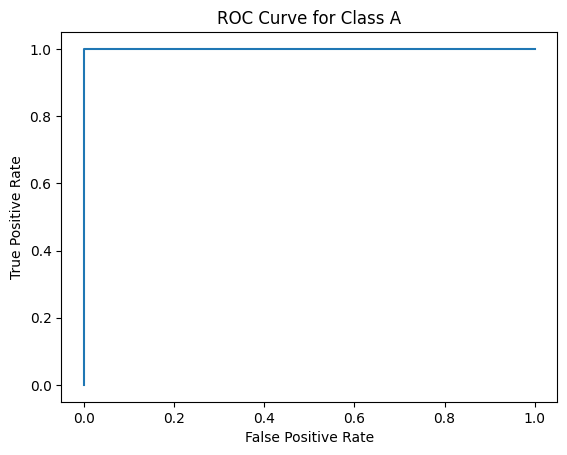

AUC for class A: 0.9999860578355835


In [5]:
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer, StandardScaler
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/content/letter-recognition.csv")

# Features and labels
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Train-test split
X_train, X_test, y_train_labels, y_test_labels = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Binarize labels (needed for ROC)
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(y_train_labels)
y_test_bin = lb.transform(y_test_labels)

# Train SVM
model = svm.SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train_labels)

# Predictions
y_pred = model.predict(X_test)

# Accuracy & Confusion Matrix
print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_labels, y_pred))


# -------------------------------
# ROC & AUC (Fixed)
# -------------------------------
# Use predict_proba instead of decision_function (better for ROC in multi-class)
y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(lb.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC for first class
plt.plot(fpr[0], tpr[0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve for Class {lb.classes_[0]}")
plt.show()

print(f"AUC for class {lb.classes_[0]}:", roc_auc[0])